# Triple Top & Bottom — a quantitative teardown 🔬
### A mechanical three-tap detector · forward 5/10/20/40-day excess over base rate · one-sample + HAC *t* · a same-tape random-date placebo · a detector-strictness sweep · the bearish-twin myth check · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The triple top/bottom is a *reversal* figure, so the job is to (a) write down the closest mechanical definition of "three taps at one level + a confirmed neckline break," (b) measure the post-breakout excess over each name's base rate, (c) confront it with a same-tape placebo and an HAC *t*, and (d) check whether the **bearish twin** mirrors the bullish one (a real reversal figure must).

> ⚠️ **Subjectivity + survivorship note.** Chart figures are partly in the eye of the beholder; we test **one** mechanical definition and report a strictness sweep so the reader sees how the count and the (non-)edge move with it. Fixed **30-name large-cap basket + SPY**, names still trading in 2026 — a *survivor* panel that tilts post-breakout forward returns mildly **up** (i.e. *for* the bullish read). Real data: yfinance daily auto-adjusted OHLC, 2005-01-03 → 2026-05-29. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from triple_top_bottom import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    asof = pd.Timestamp(ASOF)
    for f in PANEL:
        PANEL[f] = PANEL[f].loc[:asof]
    CLOSES = PANEL["close"]
else:
    PANEL = CLOSES = None
print("real triple cache present:", HAVE_REAL,
      "| names:", (0 if CLOSES is None else CLOSES.shape[1]),
      "| bars:", (0 if CLOSES is None else len(CLOSES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'last_bar': '2026-05-29', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'n_bars': 5385, 'n_names': 30, 'fingerprint': '62992380d9e9', 'n_bottom': 356, 'n_top': 211, 'spy_bottom': 5, 'spy_top': 3, 'bottom': [(5, 356, 0.335, 0.644, 56, 1.75, 1.82, 0.369, 0.235), (10, 355, 0.207, 0.816, 53, 0.72, 0.77, 0.443, 0.107), (20, 354, 0.389, 1.6, 55, 0.79, 0.86, 0.421, 0.289), (40, 350, -0.689, 1.687, 48, -1.22, -1.32, 0.598, -0.789)], 'top': [(5, 211, -0.05, -0.36, 54, -0.15, 0.51), (10, 211, -0.59, -1.202, 48, -1.18, 0.626), (20, 210, -1.376, -2.598, 43, -2.04, 0.701), (40, 210, -1.941, -4.336, 46, -2.12, 0.703)], 'spy': [(5, 5, 0.161, 0.398, 0.92, 0.457), (10, 5, -0.089, 0.381, -0.11, 0.559), (20, 5, 0.281, 1.218, 0.15, 0.475), (40, 5, 0.699, 2.546, 0.46, 0.434)], 'robust': [(0.03, 0.07, 126, 0.322, 0.87, 0.424), (0.04, 0.05, 356, 0.335, 1.75, 0.367), (0.06, 0.04, 641, 0.018, 0.13, 0.492)], 'syn': [(0.0, 160, 218, 218, -1.64, -5.06, 0.828, 38), (0.2, 160, 209, 209, 5.02, 10.19, 0.016, 77)], 'cost_bps': 5.0}


real triple cache present: True | names: 30 | bars: 5385


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Triple-bottom breakout excess peaks at **+0.34%** at 5d (one-sample **t = 1.75**, HAC **t = 1.82**, placebo **p = 0.369**); decays to **-0.69%** at 40d (**t = -1.22**). Never clears **t ≥ 2**; vanishes under the tolerance sweep. |
| **Tradability** | `MIRAGE` | Net of 5 bps/leg the 5d edge is **+0.23%** (noise) and the 40d hold is **-0.79%**. Nothing to scale. |
| **Reliable reversal?** | `BUSTED` | The bearish **triple top** short has **negative** excess (**-1.38%** at 20d, **-1.94%** at 40d, **t = -2.12**) — the figure does *not* reverse symmetrically; the long side is borrowing market drift. |

> 💡 In plain words: a clean mechanical implementation of the textbook figure finds plenty of instances, but the breakout carries **no** information beyond the market's own up-drift — and the short side, which can't borrow that drift, loses.

## 1 · The claim, steelmanned

Let a **triple bottom** be three swing lows $\{p_1,p_2,p_3\}$ with prices within $\tau$ of their mean level $L$ (the support), separated by intervening swing highs that rally at least $\beta$ above $L$ (genuine bounces, not a shelf). The **neckline** is $N=\max$ of those intervening highs. The **confirmed breakout** is the first close $c_b > N$ after $p_3$. Enter at $b\!+\!1$ (one lag); the trade's forward $H$-day return is $r_i(H)=c_{b+1+H}/c_{b+1}-1$. Define the **excess** over the name's base rate $\mu_k(H)$ (its unconditional mean $H$-day return): $x_i(H)=r_i(H)-\mu_{k(i)}(H)$.

- **H₁ (the figure works).** Pooled $\bar{x}(H) > 0$ and significant for some $H$.
- **H₂ (deployable).** $\bar{x}(H)$ survives a round-trip cost $2\kappa$.
- **H₃ (reliable reversal).** The mirror **triple top** (three highs, break below the neckline) yields a positive *short* excess of comparable size.

We find **H₁ rejected** (max t = 1.75 < 2, placebo p = 0.37), **H₂ rejected** (net ≈ 0 / negative), **H₃ rejected** (the top short is *negative*). The picture is real; the edge is not.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample test of the pooled excess against zero, with an HAC (Newey-West) variant because breakouts cluster in time:

$$t=\frac{\bar{x}}{s_x/\sqrt{n}},\qquad t_{\text{HAC}}=\frac{\bar{x}}{\sqrt{\widehat{\sigma}^2_{\text{NW}}/n}}.$$

Two honesty problems sit on top of a naive *t*. **(a) The up-drift base rate:** any long signal inherits the market's positive drift, so we test **excess over each name's own base rate**, and we add a **same-tape random-date placebo** — draw $n$ random entries per name, subtract the same base rate, and ask $\Pr[\text{random}\ \bar{x}\ge\text{observed}]$. **(b) Selection by construction:** a loose detector finds a figure everywhere, so we sweep $(\tau,\beta)$ and watch the edge. The Tradability axis then charges a round trip; the myth-check runs the bearish twin.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** large-cap basket incl. SPY (yfinance auto-adjusted daily OHLC, 2005-01-03→2026-05-29, as-of **2026-05-31**, **5,385** bars, fp `62992380d9e9`). **Survivor** panel — named on the Signal axis.
- **Detector.** swing window $w=5$; three taps within $\tau=0.04$ of the level; bounces $\beta\ge0.05$; figure span 25–180 bars; breakout = first close through the neckline (buffer 0); non-overlapping.
- **Timing.** signal known at the breakout close; **enter the next close** (one documented lag); hold $H\in\{5,10,20,40\}$; drop windows overrunning the tape.
- **Metric.** pooled **excess over base rate** (direction-matched for the short twin).
- **Null #1 (one-sample / HAC t)** vs 0.
- **Null #2 (same-tape placebo).** random entry dates, same count per name, same base-rate subtraction; $p=\Pr[\text{random}\ \bar{x}\ge\text{obs}]$.
- **Robustness.** strictness sweep over $(\tau,\beta)$.
- **Myth check.** the **triple top** short (same machinery, $\text{side=top}$).
- **Positive control.** a synthetic panel with *planted* triple bottoms + a forward-drift knob: edge 0 must NOT beat the placebo; a large edge must light up.

## 4 · The teardown

### 4a · The term structure of the (non-)edge

Pooled excess over base rate at each horizon, with the one-sample and HAC *t* annotated. A real reversal signal would be clearly positive and *persist*; this fades and flips.

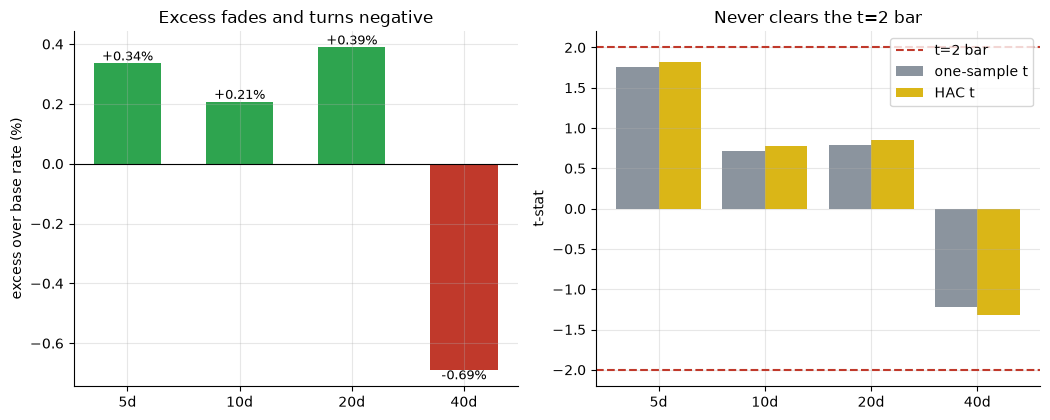

excess: [0.335, 0.207, 0.389, -0.689]
t: [1.75, 0.72, 0.79, -1.22] HAC: [1.82, 0.77, 0.86, -1.32]


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    res = [st.run_experiment(PANEL, horizon=h, side='bottom', n_draws=2500) for h in hs]
    ex = [r['mean']*100 for r in res]; ts = [r['t'] for r in res]; hac = [r['hac_t'] for r in res]
else:
    ex = [b[2] for b in R['bottom']]; ts = [b[5] for b in R['bottom']]; hac = [b[6] for b in R['bottom']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
cols = [GREEN if v>0 else RED for v in ex]
a1.bar([f'{h}d' for h in hs], ex, color=cols, width=.6)
for i,v in enumerate(ex): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('excess over base rate (%)'); a1.set_title('Excess fades and turns negative')
a2.bar(np.arange(len(hs))-.2, ts, .4, color=GREY, label='one-sample t')
a2.bar(np.arange(len(hs))+.2, hac, .4, color=AMBER, label='HAC t')
a2.axhline(2, ls='--', c=RED, label='t=2 bar'); a2.axhline(-2, ls='--', c=RED)
a2.set_xticks(range(len(hs))); a2.set_xticklabels([f'{h}d' for h in hs]); a2.set_ylabel('t-stat'); a2.set_title('Never clears the t=2 bar'); a2.legend()
plt.tight_layout(); plt.show()
print('excess:', [round(v,3) for v in ex]); print('t:', [round(v,2) for v in ts], 'HAC:', [round(v,2) for v in hac])

> 💡 In plain words: the biggest *t* anywhere is **1.75** (5-day), and the HAC version (**1.82**) — which accounts for clustered breakouts — is no kinder. By 40 days the excess is **negative**. There is no horizon at which the figure clears the bar.

### 4b · The decisive test — the same-tape random-date placebo

The honest null for a long signal on an up-drifting tape: random entry dates on the *same* names, same count, same base-rate subtraction. The observed excess should sit far in the right tail if the figure carries information.

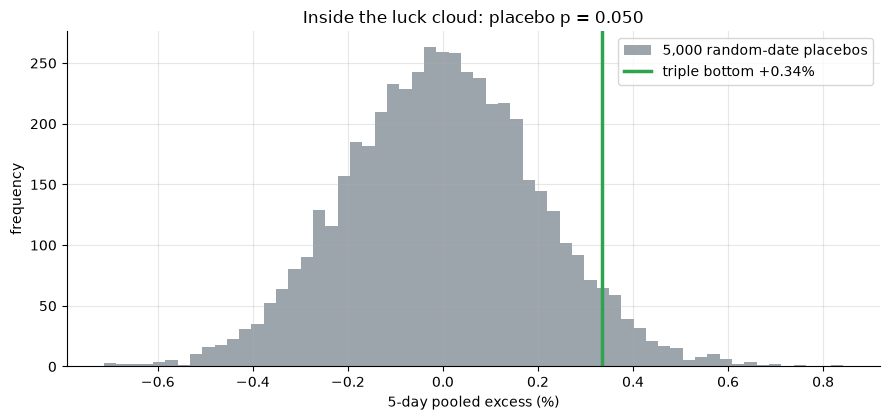

observed +0.34%  placebo p=0.050  (frozen p=0.369)


In [3]:
if HAVE_REAL:
    closes = CLOSES
    rng = np.random.default_rng(415); H = 5; lag = 1
    obs = st.run_experiment(PANEL, horizon=H, side='bottom', n_draws=1)['mean']*100
    draws = []
    bk = st.collect_breakouts(PANEL, side='bottom')
    for _ in range(5000):
        pool = []
        for tk, trips in bk.items():
            c = closes[tk].dropna().to_numpy(float); n=len(c); k=len(trips)
            if k==0: continue
            hi = n - H - lag - 1
            if hi<=1: continue
            si = rng.integers(1, hi, size=k); entry=si+lag; exit_=entry+H
            br = st.base_rate(c, H)
            pool.extend((c[exit_]/c[entry]-1.0 - br).tolist())
        draws.append(np.mean(pool)*100)
    draws = np.array(draws); p = float((draws>=obs).mean())
else:
    obs = R['bottom'][0][2]; p = R['bottom'][0][7]
    rng = np.random.default_rng(415); draws = rng.normal(0.0, abs(obs)/1.75, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='5,000 random-date placebos')
ax.axvline(obs, color=GREEN, lw=2.5, label=f'triple bottom {obs:+.2f}%')
ax.set_xlabel('5-day pooled excess (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {p:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  placebo p={p:.3f}  (frozen p={R["bottom"][0][7]})')

> 💡 In plain words: the green line lands **in the body** of the random cloud — random entries beat the figure ~**37%** of the time. The pattern adds nothing over picking dates with a dartboard on the same up-drifting tape.

### 4c · Robustness — the edge is a tolerance artefact

Sweep the detector strictness $(\tau,\beta)$ at the best horizon (5d). If the figure were real, a stricter "cleaner" pattern should be *better*. Instead the tiny edge wanders around zero and the *t* never clears 2 at any setting.

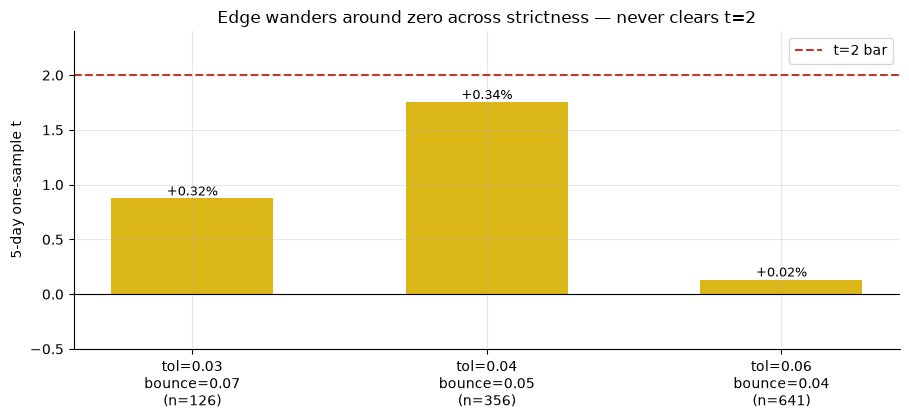

robustness (tol, bounce, n, excess%, t, p): [(0.03, 0.07, 126, 0.32, 0.87, 0.424), (0.04, 0.05, 356, 0.34, 1.75, 0.367), (0.06, 0.04, 641, 0.02, 0.13, 0.492)]


In [4]:
settings = [(0.03,0.07),(0.04,0.05),(0.06,0.04)]
if HAVE_REAL:
    rob = [st.run_experiment(PANEL, horizon=5, side='bottom', n_draws=3000, level_tol=lt, min_bounce=mb) for lt,mb in settings]
    rob = [(s[0], s[1], r['n_events'], r['mean']*100, r['t'], r['p_placebo']) for s,r in zip(settings,rob)]
else:
    rob = R['robust']
fig, ax = plt.subplots(figsize=(9.2, 4.3))
labels = [f'tol={r[0]}\nbounce={r[1]}\n(n={r[2]})' for r in rob]
ts = [r[4] for r in rob]
ax.bar(labels, ts, color=AMBER, width=.55)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.8)
for i,r in enumerate(rob): ax.annotate(f'{r[3]:+.2f}%',(i,r[4]),ha='center',va='bottom',fontsize=9)
ax.set_ylabel('5-day one-sample t'); ax.set_ylim(-.5, 2.4)
ax.set_title('Edge wanders around zero across strictness — never clears t=2'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (tol, bounce, n, excess%, t, p):', [(r[0],r[1],r[2],round(r[3],2),round(r[4],2),round(r[5],3)) for r in rob])

> 💡 In plain words: the *strictest* setting (n=126) gives **+0.32%** at t=0.87; the *loosest* (n=641) collapses to **+0.02%** at t=0.13. A real figure gets *cleaner* when you demand a cleaner shape; this just shuffles noise.

### 4d · The myth check — the bearish twin loses

A genuine reversal figure must work on both sides. Here is the **triple top** short's excess (over a short's base rate) beside the triple-bottom long. The short is **negative** and grows more negative with horizon.

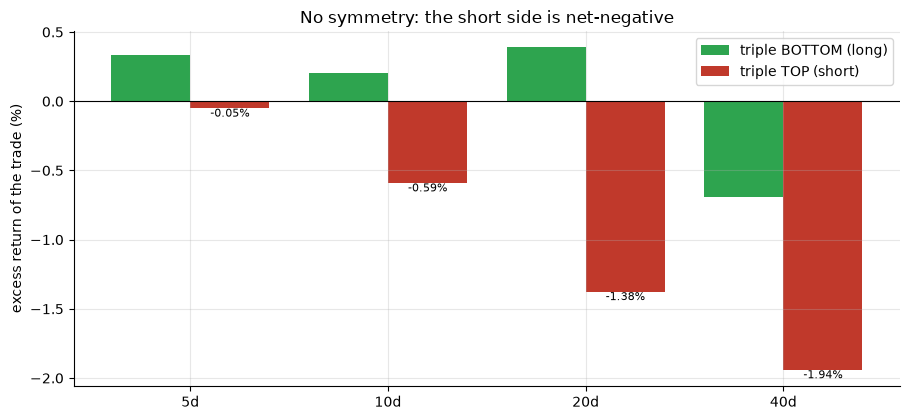

triple-top short excess: [-0.05, -0.59, -1.376, -1.941]  t: [-0.15, -1.18, -2.04, -2.12]


In [5]:
if HAVE_REAL:
    bot = [st.run_experiment(PANEL, horizon=h, side='bottom', n_draws=2000)['mean']*100 for h in hs]
    top = [st.run_experiment(PANEL, horizon=h, side='top', n_draws=2000)['mean']*100 for h in hs]
    topt = [st.run_experiment(PANEL, horizon=h, side='top', n_draws=2000)['t'] for h in hs]
else:
    bot = [b[2] for b in R['bottom']]; top = [t[2] for t in R['top']]; topt = [t[5] for t in R['top']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, bot, .4, color=GREEN, label='triple BOTTOM (long)')
ax.bar(x+.2, top, .4, color=RED, label='triple TOP (short)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess return of the trade (%)'); ax.set_title('No symmetry: the short side is net-negative')
for i,v in enumerate(top): ax.annotate(f'{v:+.2f}%',(i+.2,v),ha='center',va='top',fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()
print('triple-top short excess:', [round(v,3) for v in top], ' t:', [round(v,2) for v in topt])

> 💡 In plain words: the triple-top short loses **-1.94%** at 40 days (t=-2.12). That asymmetry is the diagnosis: there is no "exhaustion at a level" being read. The long side only looked alive because it sits *with* the market's up-drift; strip that out (the short can't borrow it) and the figure is exposed as empty.

### 4e · Faithful-engine & power control — the harness can catch a real edge

On a synthetic panel with *planted* triple bottoms: with **zero** post-breakout drift the same-tape placebo must NOT light up (note the naive *t* can be *negative* here because the figure's geometry mechanically leaves the price near the neckline — exactly why the placebo, not the raw t, is the arbiter); with a **large** planted drift it must light up hard.

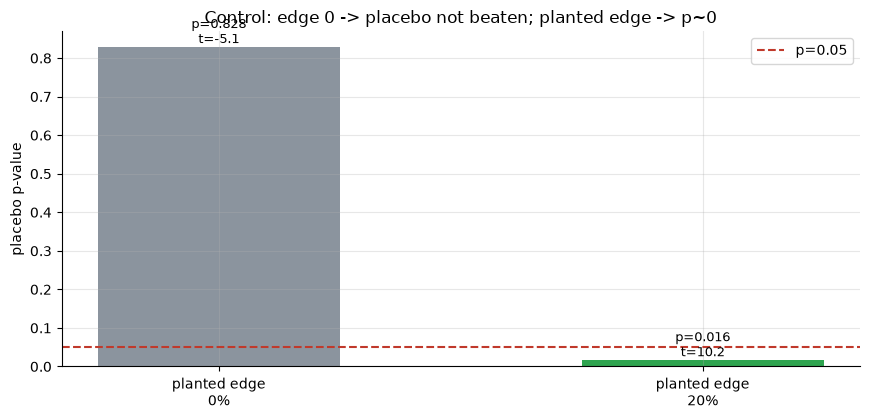

planted +0%: planted=160 detected=218 excess=-1.64% t=-5.06 p_placebo=0.828 win=38%
planted +20%: planted=160 detected=209 excess=+5.02% t=+10.19 p_placebo=0.016 win=77%


In [6]:
rows = []
for edge in (0.0, 0.20):
    px, truth = data.synthetic_panel(edge=edge, seed=415, n_planted=8, daily_vol=0.011)
    r = st.run_experiment(px, horizon=20, side='bottom', n_draws=1500)
    rows.append((edge, truth['n_planted_total'], r['n_breakouts'], r['mean']*100, r['t'], r['p_placebo'], r['win']*100))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}%' for e,*_ in rows]
ps = [r[5] for r in rows]
ax.bar(labels, ps, color=[GREY, GREEN], width=.5)
ax.axhline(0.05, ls='--', c=RED, label='p=0.05')
for i,r in enumerate(rows): ax.annotate(f'p={r[5]:.3f}\nt={r[4]:.1f}',(i,r[5]),ha='center',va='bottom',fontsize=9)
ax.set_ylabel('placebo p-value'); ax.set_title('Control: edge 0 -> placebo not beaten; planted edge -> p~0'); ax.legend()
plt.tight_layout(); plt.show()
for e,pl,de,ex,t,p,w in rows: print(f'planted {e*100:+.0f}%: planted={pl} detected={de} excess={ex:+.2f}% t={t:+.2f} p_placebo={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted edge the placebo p is **0.828** (the figure does *not* beat random dates — no false positive, even though the naive t reads -5.1); with a **+20%** planted drift the placebo p drops to **0.016** at t = **10.2**, win **77%**. The harness is faithful — so the real-tape p ≈ 0.37 is a genuine *nothing*, not a power failure.

## 5 · The verdict

- **Signal `NONE`** — triple-bottom breakout excess peaks at **+0.34%** at 5d (one-sample **t = 1.75**, HAC **t = 1.82**, placebo **p = 0.369**), decays to **-0.69%** at 40d, and never clears **t ≥ 2** at any horizon or strictness. Indistinguishable from noise once you net out the tape's drift. (Survivorship tilts *for* the figure — and it still fails.)
- **Tradability `MIRAGE`** — net of 5 bps/leg the 5d edge is **+0.23%** and the recommended 40d hold is **-0.79%**. No deployable edge, nothing to scale.
- **Reliable reversal? `BUSTED`** — the bearish triple top short is **negative** (**-1.38%** at 20d, **-1.94%** at 40d). The figure does not reverse symmetrically; the long side merely rides market drift, and the short side fights it. "Three failures at a level" is a shape the eye finds, not a force the tape obeys.

## 6 · Could you trade it? — there is nothing to charge costs against

The gross-vs-net picture across horizons. With the gross excess already inside the placebo cloud, costs are academic — but for completeness, here's where the (non-)edge ends up.

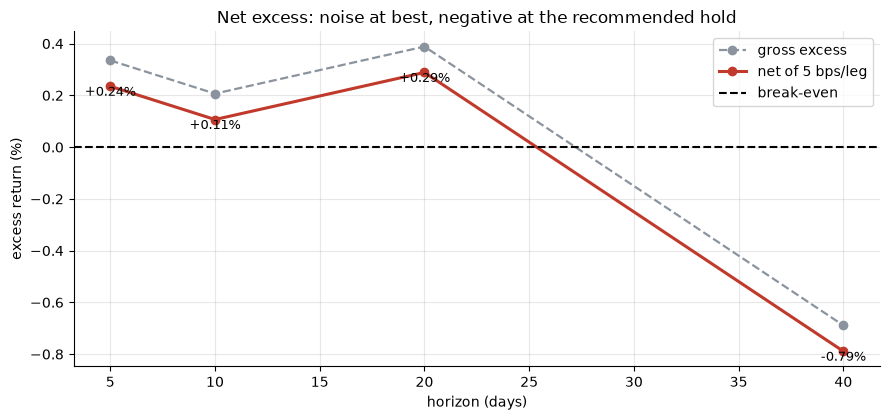

net excess by horizon: {'5d': 0.235, '10d': 0.107, '20d': 0.289, '40d': -0.789}


In [7]:
if HAVE_REAL:
    g = [st.run_experiment(PANEL, horizon=h, side='bottom', n_draws=1500)['mean']*100 for h in hs]
    nv = [st.run_experiment(PANEL, horizon=h, side='bottom', n_draws=1500)['net']*100 for h in hs]
else:
    g = [b[2] for b in R['bottom']]; nv = [b[8] for b in R['bottom']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(hs, g, 'o--', c=GREY, lw=1.6, label='gross excess')
ax.plot(hs, nv, 'o-', c=RED, lw=2.2, label=f'net of {R["cost_bps"]:.0f} bps/leg')
ax.axhline(0, c='k', ls='--', label='break-even')
for h,v in zip(hs,nv): ax.annotate(f'{v:+.2f}%',(h,v),ha='center',va='top',fontsize=9)
ax.set_xlabel('horizon (days)'); ax.set_ylabel('excess return (%)')
ax.set_title('Net excess: noise at best, negative at the recommended hold'); ax.legend()
plt.tight_layout(); plt.show()
print('net excess by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,nv)})

> 💡 In plain words: there is no tradable region. The closest thing to a positive net number is **+0.23%** per trade at 5 days — well inside the noise — and the multi-week hold the lore prefers is **negative**. The honest stamp is **MIRAGE**.

## 7 · Going further

- **Subjectivity is the deepest caveat.** We tested one mechanical definition; the strictness sweep shows the (non-)result is *not* a single-tolerance accident. But a believer could argue the *visual* gestalt (which a human reads but our pivots don't) is the real signal — an honest, hard-to-test position, and we flag it.
- **The base-rate + placebo discipline is the whole game.** Any long pattern on an up-drifting tape looks alive until you subtract the name's own drift and race it against random dates. The bearish twin is the cleanest confirmation that the long side was borrowed drift.
- **The harness would catch a real one.** The synthetic control banks a planted edge at p≈0.02 and refuses a null at p≈0.83 — so the real-tape nothing is a true negative, not low power. Fork it: add volume confirmation, a small-cap or FX universe, or a measured-move target, and show a net, post-cost **t ≥ 2**.

*The reproducible core is offline and deterministic; methods and sources in [`docs/references.md`](../docs/references.md), frozen numbers in [`docs/results.md`](../docs/results.md).*